### Multivariate LTSM For Predicting Future CPU Usage

Phase 4A: 
Forecast 1 hour ahead
We will use: Last 12 observations
because:
12 × 5 minutes = 1 hour history
Model sees: Previous 1 hour and predicts:
Next CPU state

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping
)

In [2]:
# Load Feature Dataset
df = pd.read_csv(
    "../data/Processed/cpu_features.csv"
)

df["ts"] = pd.to_datetime(
    df["ts"],
    format="mixed",
    utc=True
)

In [3]:
# Sort chronologically
df = df.sort_values(
    ["hostName", "ts"]
)

df = df.reset_index(drop=True)

In [4]:
# Select Features
FEATURES = [
    "cpu_usage_pct",
    "memory_usage_pct",
    "power_kw",
    "cpu_temp_c",
    "inlet_temp_c",
    "cpu_lag_1",
    "cpu_lag_2",
    "cpu_change",
    "cpu_acceleration",
    "cpu_volatility",
    "cpu_memory_ratio",
    "thermal_gradient",
    "temp_rate_of_change",
    "cpu_per_kw",
    "temp_per_cpu",
    "resource_stress_index"
]

TARGET = "cpu_usage_pct"

In [5]:
# Extract Data
data = df[FEATURES]

In [6]:
# Scale Data
# LSTMs require normalised inputs
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)

Create Sequences
We want:
Previous 12 observations which equals: 1 hour history because: 12 × 5 minutes
Example: Input:
t1
t2
t3
...
t12
Predict: t13

In [7]:
# Sequence Function, create sequences per server
def create_sequences_per_server(
    df,
    features,
    sequence_length=12
):
    X = []
    y = []
    for host in df["hostName"].unique():
        server_df = df[
            df["hostName"] == host
        ].copy()
        server_df = server_df.sort_values(
            "ts"
        )
        scaler = MinMaxScaler()

        scaled = scaler.fit_transform(
            server_df[features]
        )
        target_index = features.index(
            "cpu_usage_pct"
        )

        for i in range(
            sequence_length,
            len(scaled)
        ):
            X.append(
                scaled[
                    i-sequence_length:i
                ]
            )
            y.append(
                scaled[
                    i,
                    target_index
                ]
            )
    return (
        np.array(X),
        np.array(y)
    )

In [8]:
X, y = create_sequences_per_server(
    df,
    FEATURES,
    sequence_length=12
)

In [9]:
# Verify shapes
print(X.shape)
print(y.shape)

(74216, 12, 16)
(74216,)


In [10]:
# Train-test split
train_size = int(
    len(X) * 0.8
)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [11]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(59372, 12, 16)
(14844, 12, 16)
(59372,)
(14844,)


In [12]:
# Build the LSTM model
model = Sequential()
model.add(
    LSTM(
        64,
        return_sequences=True,
        input_shape=(
            X_train.shape[1],
            X_train.shape[2]
        )
    )
)
model.add(
    Dropout(0.2)
)
model.add(
    LSTM(32)
)
model.add(
    Dropout(0.2)
)
model.add(
    Dense(16, activation="relu")
)
model.add(
    Dense(1)
)

c:\Users\Avilasha\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 64)         │        20,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,697 (131.63 KB)

 Trainable params: 33,697 (131.63 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Early Stopping
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [16]:
# Training Cell
history = model.fit(
    X_train,
    y_train,

    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
743/743 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.0042 - mae: 0.0419 - val_loss: 0.0029 - val_mae: 0.0367
Epoch 2/30
743/743 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.0034 - mae: 0.0380 - val_loss: 0.0018 - val_mae: 0.0238
Epoch 3/30
743/743 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0033 - mae: 0.0373 - val_loss: 0.0019 - val_mae: 0.0224
Epoch 4/30
743/743 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0033 - mae: 0.0367 - val_loss: 0.0019 - val_mae: 0.0228
Epoch 5/30
743/743 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0032 - mae: 0.0362 - val_loss: 0.0018 - val_mae: 0.0221
Epoch 6/30
743/743 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0032 - mae: 0.0361 - val_loss: 0.0019 - val_mae: 0.0221
Epoch 7/30
743/743 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0032 - mae: 0.0358 - val_loss: 0.0018 - val_mae: 0.0221
Epoch 8/30
743/743 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0031 - mae: 0.0356 - val_loss: 0.0017 - val_mae: 0.0220
Epoch 9/30
743/743 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - 

In [17]:
history.history.keys()

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])

Prediction and Forecasting

In [18]:
# Generate Predictions
y_pred = model.predict(X_test)
print(y_pred.shape)

464/464 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
(14844, 1)


In [19]:
# Flatten predictions
y_pred = y_pred.flatten()
print(y_pred.shape)

(14844,)


Evaluate Model Predictions

In [20]:
# MAE
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
mae = mean_absolute_error(
    y_test,
    y_pred
)
print("MAE:", mae)

MAE: 0.010019780707636743


In [21]:
# RMSE
rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)
print("RMSE:", rmse)

RMSE: 0.029973536786665093


In [22]:
# R2 Score
r2 = r2_score(
    y_test,
    y_pred
)
print("R2 Score:", r2)

R2 Score: 0.5401327241307241


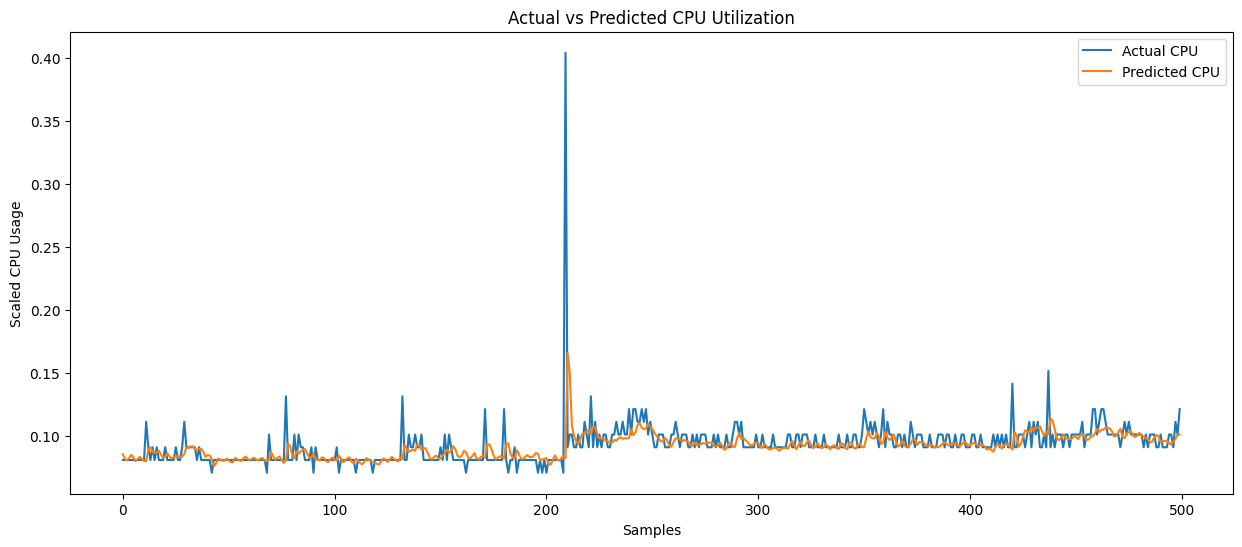

In [23]:
# Visualize Forecast Performance
plt.figure(figsize=(15,6))
plt.plot(
    y_test[:500],
    label="Actual CPU"
)
plt.plot(
    y_pred[:500],
    label="Predicted CPU"
)
plt.title(
    "Actual vs Predicted CPU Utilization"
)

plt.xlabel("Samples")
plt.ylabel("Scaled CPU Usage")
plt.legend()
plt.show()

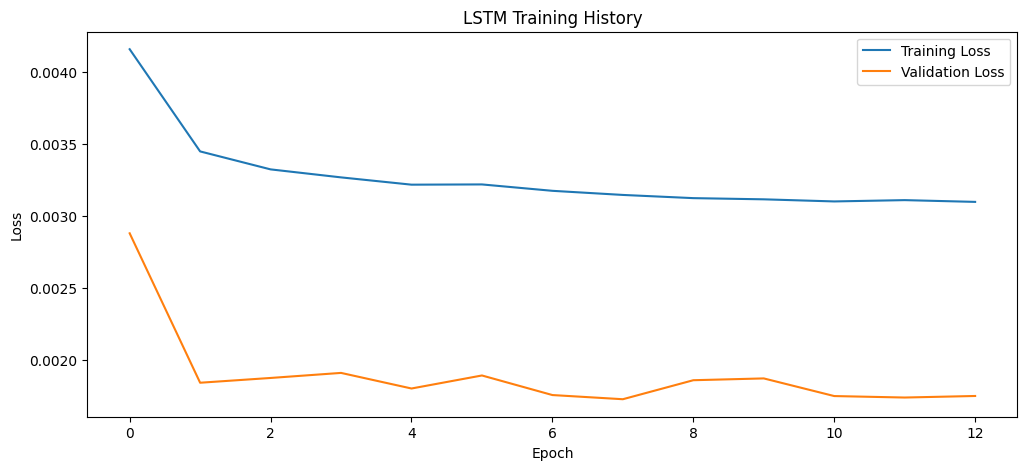

In [24]:
# Training History Plot
plt.figure(figsize=(12,5))
plt.plot(
    history.history["loss"],
    label="Training Loss"
)
plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("LSTM Training History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

CPU Overload Prediction

In [25]:
# threshold to be defined
CPU_THRESHOLD = 0.80
future_overloads = (
    y_pred > CPU_THRESHOLD
)
print(
    "Predicted Overload Events:",
    future_overloads.sum()
)

Predicted Overload Events: 0
